Análisis adicional de criterios de clustering

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

unificar datasets


In [106]:
archivos = ['lunes-03-11.csv', 'martes-11-11.csv', 'miercoles-12-11.csv',
            'jueves-06-11.csv', 'viernes-14-11.csv']

df_raw = pd.concat([pd.read_csv(f) for f in archivos], ignore_index=True)

In [107]:
def preprocesar_datos(df):
    df_new = df.copy()

    # Transformación Cíclica de la Hora (24hs)
    horas_dt = pd.to_datetime(df_new['Hora_Inicio'], format='%H:%M:%S')
    segundos_dia = horas_dt.dt.hour * 3600 + horas_dt.dt.minute * 60 + horas_dt.dt.second
    df_new['hora_seno'] = np.sin(2 * np.pi * segundos_dia / 86400)
    df_new['hora_coseno'] = np.cos(2 * np.pi * segundos_dia / 86400)


    df_new = pd.get_dummies(df_new, columns=['Dia_Semana'], prefix='dia') # One-Hot Encoding para Día de la Semana

    df_new['Hora_Num'] = segundos_dia / 3600

    return df_new

df_procesado = preprocesar_datos(df_raw)

Escalado de datos - Seleccionando las columnas para el modelo

In [ ]:
cols_dia = [c for c in df_procesado.columns if c.startswith('dia_')]
features = ['Total_Vehiculos', 'Ocupacion_Espacial_%', 'Tiempo_Medio_s'] 

X = df_procesado[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducción a 3 componentes principales (PCA)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
display(X.head())

,Total_Vehiculos,Ocupacion_Espacial_%,Tiempo_Medio_s,hora_seno,hora_coseno,dia_1,dia_2,dia_3,dia_4,dia_5
0,8,21.68,3.24,0.866824,-0.498614,True,False,False,False,False
1,7,18.81,1.21,0.865443,-0.501007,True,False,False,False,False
2,4,9.68,2.80,0.864055,-0.503397,True,False,False,False,False
3,7,16.25,2.00,0.862661,-0.505783,True,False,False,False,False
4,6,16.44,2.72,0.861260,-0.508165,True,False,False,False,False


CLUSTERING K=4

In [109]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_raw['Cluster_PCA'] = kmeans.fit_predict(X_pca)

RESULTADOS

/tmp/ipykernel_10812/2664526378.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='Cluster_PCA', y=df_procesado['Hora_Num'],


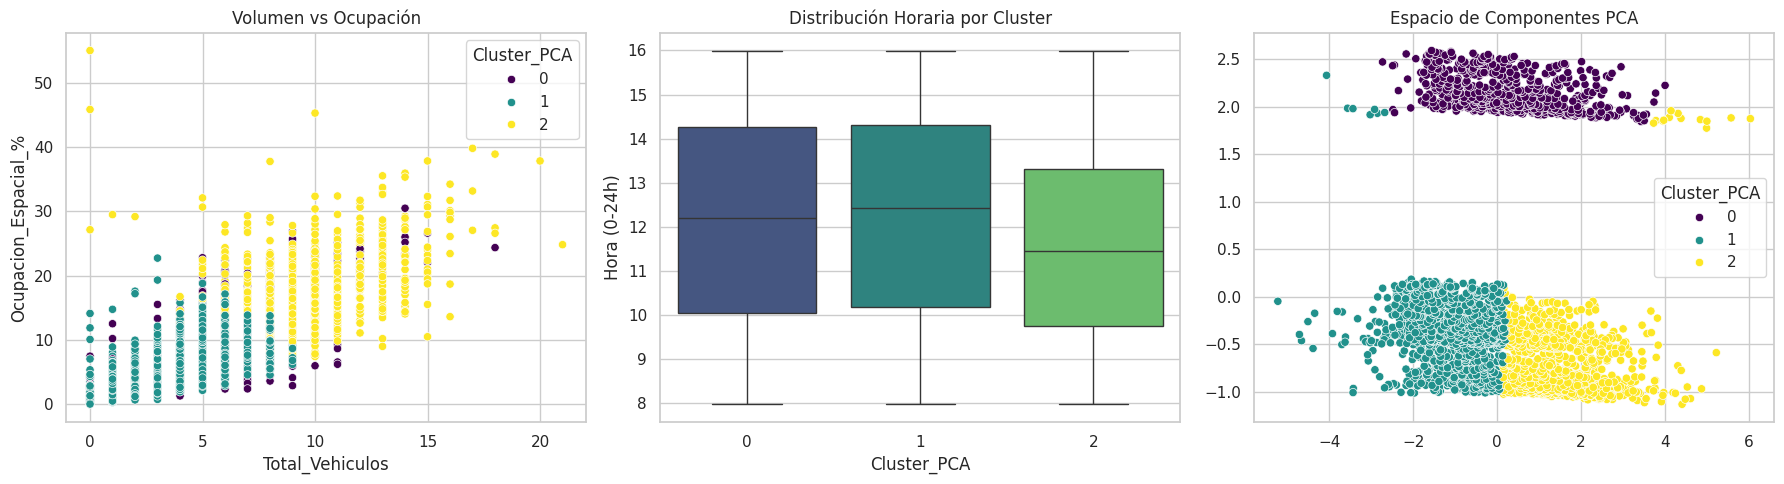

In [110]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Dispersión Tráfico
sns.scatterplot(data=df_raw, x='Total_Vehiculos', y='Ocupacion_Espacial_%',
                hue='Cluster_PCA', palette='viridis', ax=axes[0])
axes[0].set_title('Volumen vs Ocupación')

# Gráfico 2: Distribución Horaria
sns.boxplot(data=df_raw, x='Cluster_PCA', y=df_procesado['Hora_Num'],
            palette='viridis', ax=axes[1])
axes[1].set_title('Distribución Horaria por Cluster')
axes[1].set_ylabel('Hora (0-24h)')

# Gráfico 3: PCA 2D
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_raw['Cluster_PCA'],
                palette='viridis', ax=axes[2])
axes[2].set_title('Espacio de Componentes PCA')

plt.tight_layout()
plt.show()

In [111]:

df_raw.to_csv('dataset_consolidado_clustering2.csv', index=False)

print("--- Resumen de Clusters ---")
print(df_raw.groupby('Cluster_PCA')[['Total_Vehiculos', 'Ocupacion_Espacial_%', 'Tiempo_Medio_s']].mean())
print("\nProceso finalizado. Archivo 'dataset_consolidado_clustering2.csv' guardado.")

--- Resumen de Clusters ---
             Total_Vehiculos  Ocupacion_Espacial_%  Tiempo_Medio_s
Cluster_PCA                                                       
0                   5.980519             11.277727        2.840714
1                   4.020624              6.749822        3.690056
2                   8.872272             16.596039        2.341099

Proceso finalizado. Archivo 'dataset_consolidado_clustering2.csv' guardado.
